In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Define the path to the CSV file
csv_file_path = '/content/drive/MyDrive/ml_project/Team-6/sampling/yelp_subset_tucson_15k.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,is_positive
0,-mqCkxEbdoSsteq0cku56w,4PFwh5zbgyPhTGRtxkSZZA,h8TJV8clolcjqp9aFV4OjQ,5,0,0,3,"Great Choriza and Eggs. I added jalapeños, and...",2013-12-15 19:16:48,1
1,sJy0ukIauWf1crK4mIN6Og,ya8PYKqdqdhzHUBmw0_BBw,l7FBm3yxW0dx0WqQVlcQ1Q,4,0,0,0,All I have tried was the medium sauce wings 12...,2019-09-02 04:11:45,1
2,-EJQgzb4hh5iAUyR8idcgQ,gBA3jN5d9UhL8LFJEGhx7w,JFteGsQlrJeJjur6cA1RhA,5,0,0,0,This place is awesome. Great environment. BY...,2019-03-02 01:09:10,1
3,D4hDi3wPXB4ZcuictjuCkw,SzYO8ib95493I_tuB89guw,zgb1ylb-Ic1sneuOrdEYSQ,1,0,0,0,We haven't been back here in a few years.. Sat...,2021-12-12 16:51:12,0
4,FGNtqPlhnfioCZc7NQqZ4Q,tzhNRZH08WA6nt4sRqX0Ew,52yHny8Tx6Z-k1QOojISSg,4,3,0,2,"I don't eat a lot of burgers, but I saw it jus...",2018-01-21 18:34:06,1


### 1. Target Distribution (Bar Chart)

Assuming 'stars' is the target variable for review sentiment, let's visualize its distribution using a bar chart.

/tmp/ipykernel_18674/3809528247.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=star_counts.index, y=star_counts.values, palette='viridis')


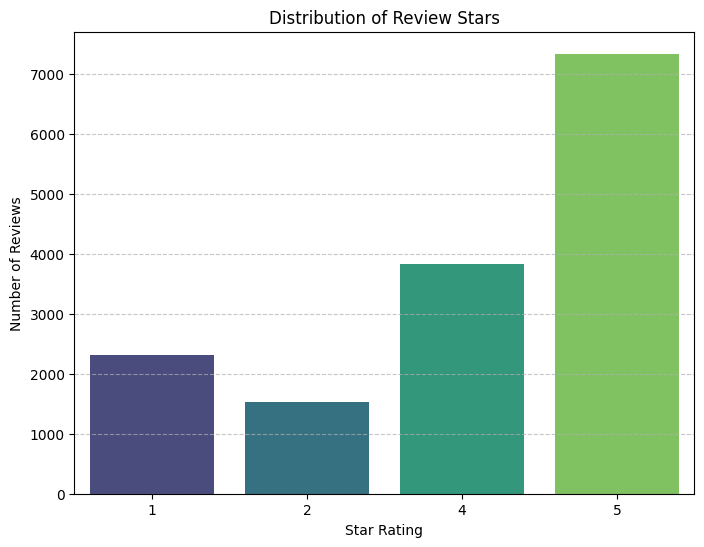

In [4]:
# Count the occurrences of each 'stars' rating
star_counts = df['stars'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=star_counts.index, y=star_counts.values, palette='viridis')
plt.title('Distribution of Review Stars')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Text Length Distribution (Box Plot)

Let's analyze the distribution of the length of the review text. This can give insights into whether longer or shorter reviews tend to have different star ratings.

/tmp/ipykernel_18674/2267793443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stars', y='text_length', data=df, palette='plasma')


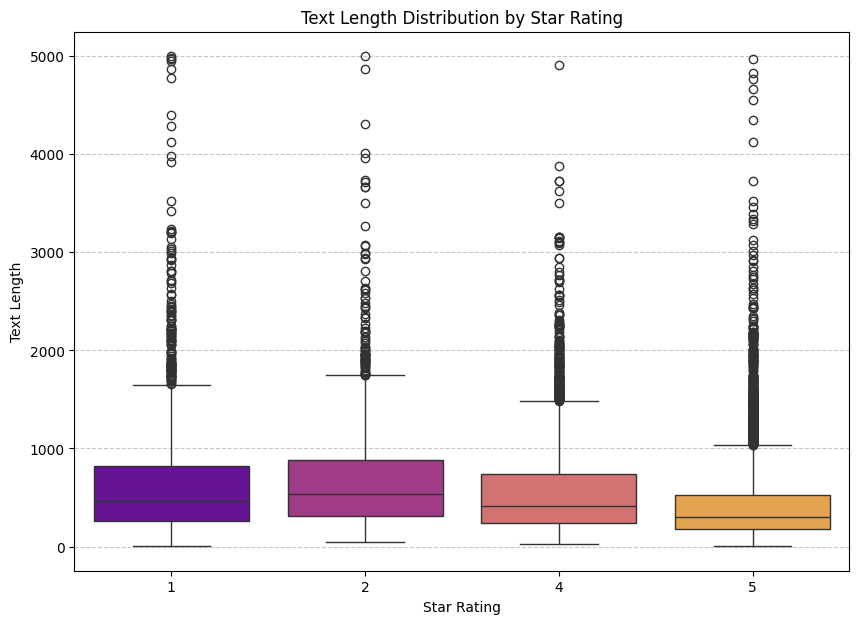

In [5]:
# Calculate the length of each review text
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 7))
sns.boxplot(x='stars', y='text_length', data=df, palette='plasma')
plt.title('Text Length Distribution by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Text Length')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Positive/Negative Word Cloud

To create word clouds, we'll first separate reviews into positive (e.g., 4-5 stars) and negative (e.g., 1-2 stars) categories and then generate word clouds for each.

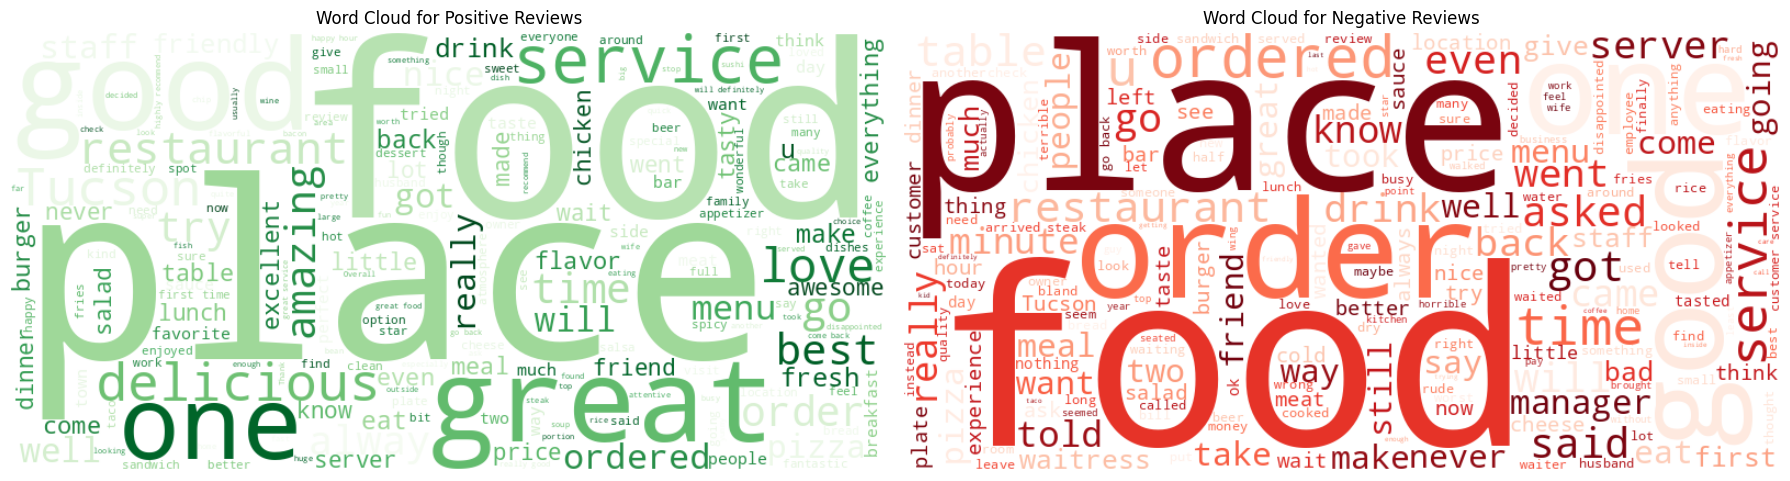

In [6]:
# Separate positive and negative reviews
positive_reviews = df[df['stars'] >= 4]['text']
negative_reviews = df[df['stars'] <= 2]['text']

# Combine all positive review text into a single string
positive_text = " ".join(review for review in positive_reviews)

# Combine all negative review text into a single string
negative_text = " ".join(review for review in negative_reviews)

# Generate Word Cloud for Positive Reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

# Generate Word Cloud for Negative Reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# Plotting the Word Clouds
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud for Positive Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud for Negative Reviews')
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
!git add .
!git commit -m "시각화 기본 코드 작성"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
